### Libraries

In [1]:
import os
import numpy as np
import nibabel as nb
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import helpers
import copy
from brainspace.mesh.mesh_io import read_surface
from brainspace.mesh.array_operations import smooth_array
from brainspace.datasets import load_mask
from brainspace.plotting import plot_hemispheres
from scipy.interpolate import griddata
from scipy.stats import zscore
from scipy import stats
import scipy as sp
import pandas as pd
import seaborn as sns
import matplotlib.colors as mcolors
import utils_RRC
import matplotlib.colors as mcolors
from statsmodels.nonparametric.smoothers_lowess import lowess

### Variables

In [2]:
# Set dataset PNI as working directory
os.chdir('/data_/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0')

# Path to MICAPIPEsurf = mask_5k !
micapipe=os.popen("echo $MICAPIPE").read()[:-1]

# Load native mid surface
inf_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.inflated.surf.gii', itype='gii')
inf_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.inflated.surf.gii', itype='gii')

mask_lh =  nb.load(micapipe + '/surfaces/fsLR-5k.L.mask.shape.gii').darrays[0].data
mask_rh =  nb.load(micapipe + '/surfaces/fsLR-5k.R.mask.shape.gii').darrays[0].data
mask_5k = np.concatenate((mask_lh, mask_rh), axis=0)
# Labels and boolean mask
mask_surf = mask_5k != 0

f5k_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.surf.gii', itype='gii')
f5k_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.surf.gii', itype='gii')

In [3]:
AFD_par_5k = np.load("/host/verges/tank/data/youngeun/myjupyter/array/AFD_par_average_SWM1mm_fsLR5k.npy")
AFD_perp_5k = np.load("/host/verges/tank/data/youngeun/myjupyter/array/AFD_perpav_average_SWM1mm_fsLR5k.npy")

### Functions

In [4]:
# Smooth intencities
def smooth_surf(surf_l, surf_r, points, Mask, Kernel='uniform', Niter=3, Relax=0.35):
    '''
    This function smooth an array (left and right) on a given surface
    Parameters
    ----------
    surf_l : np.array left surface 
    surf_r : np.array right surface
    points : np.array surface data
    Kernel : {'uniform', 'gaussian', 'inverse_distance'}
    Niter  : int, optional Number of smooth iterations
    Relax  : relax : float, optional relaxation factor
    Mask   : str or 1D ndarray, optional
    Returns
    -------
    sdata : smoothed numpy array
    
    '''
    Ndim = Mask.shape[0] 
    n2dim = int(Ndim/2)
    Mask_l=Mask[0:n2dim]
    Mask_r=Mask[n2dim:Ndim]
    sdata = np.concatenate((smooth_array(surf_l, points[0:n2dim],kernel=Kernel, n_iter=Niter,relax=Relax, mask=Mask_l), 
                          smooth_array(surf_r, points[n2dim:Ndim],kernel=Kernel, n_iter=Niter,relax=Relax, mask=Mask_r)), axis=0)
    return(sdata)

# Smooth each intencity
def smooth_intensities(int_profile):
    smoothed_i = np.copy(int_profile)
   
    # smooth each intensity
    for i in range(int_profile.shape[0]):
        smoothed_i[i,:] = smooth_surf(inf_lh, inf_rh, int_profile[i,:], mask_surf, Niter=5, Relax=0.5, Kernel='uniform')
   
    return(smoothed_i)

def map_to_labels5k(mpc_sliced, mask):
    # Get the index of the non medial wall regions
    mask_indx = np.where(mask==1)[0]
    # map to the labels
    labels_5k = np.full(mask.shape, np.nan)
    labels_5k[mask_indx] = mpc_sliced
    return(labels_5k)

## Load Geodesic distance connectome

In [5]:
# -------------------------------
# Parameters
# -------------------------------
num_bins = 20
dist_range = [0, 160]
base = "/data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0"

subjects = [
    "PNC003", "PNC006", "PNC011", "PNC018", "PNC019",
    "PNC022", "PNC024", "PNC025", "PNC026", "PNC037", "PNC038"
]

sessions = [
    "03", "03", "03", "03", "03",
    "03", "a2", "a1", "a1", "a1", "a1"
]

numFiles = len(subjects)
n_vert_l = np.sum(mask_5k[:4842] == 1)
n_vert_r = np.sum(mask_5k[4842:] == 1)

# -------------------------------
# Containers
# -------------------------------
ind_fc_hVw_l = np.zeros((numFiles, n_vert_l, num_bins))
ind_fc_evVw_l = np.zeros((numFiles, n_vert_l, num_bins))
ind_fc_hVw_r = np.zeros((numFiles, n_vert_r, num_bins))
ind_fc_evVw_r = np.zeros((numFiles, n_vert_r, num_bins))

GD_group_l = None
GD_group_r = None
FC_group_l = None
FC_group_r = None

# -------------------------------
# Subject loop
# -------------------------------
for i, (sub, ses) in enumerate(zip(subjects, sessions)):

    print(f"Processing {sub}")

    cnt_fc = (
        f"{base}/sub-{sub}/ses-{ses}/func/desc-me_task-rest_bold/surf/"
        f"sub-{sub}_ses-{ses}_surf-fsLR-5k_desc-FC.shape.gii"
    )

    cnt_gd = (
        f"{base}/sub-{sub}/ses-{ses}/dist/"
        f"sub-{sub}_ses-{ses}_surf-fsLR-5k_GD.shape.gii"
    )

    FC = nb.load(cnt_fc).darrays[0].data
    GD = nb.load(cnt_gd).darrays[0].data

    # hemisphere split
    fc_left  = FC[:4842, :4842]
    fc_right = FC[4842:, 4842:]
    gd_left  = GD[:4842, :4842]
    gd_right = GD[4842:, 4842:]

    # midwall masking
    fc_left_masked  = fc_left[np.ix_(mask_5k[:4842] == 1, mask_5k[:4842] == 1)]
    fc_right_masked = fc_right[np.ix_(mask_5k[4842:] == 1, mask_5k[4842:] == 1)]
    gd_left_masked  = gd_left[np.ix_(mask_5k[:4842] == 1, mask_5k[:4842] == 1)]
    gd_right_masked = gd_right[np.ix_(mask_5k[4842:] == 1, mask_5k[4842:] == 1)]

    # ---------------------------
    # Group FC accumulation (Fisher z)
    # ---------------------------
    FC_z_l = np.arctanh(fc_left_masked)
    np.fill_diagonal(FC_z_l, 3)

    FC_z_r = np.arctanh(fc_right_masked)
    np.fill_diagonal(FC_z_r, 3)

    if i == 0:
        FC_group_l = FC_z_l.copy()
        FC_group_r = FC_z_r.copy()
    else:
        FC_group_l += FC_z_l
        FC_group_r += FC_z_r

    if i == 0:
        GD_group_l = gd_left_masked.copy()
        GD_group_r = gd_right_masked.copy()
    else:
        GD_group_l += gd_left_masked
        GD_group_r += gd_right_masked

    # ---------------------------
    # Empirical variogram
    # ---------------------------
    hVw_l, evVw_l = helpers.emp_variogram_vwise_conn(
        fc_left_masked,
        gd_left_masked,
        num_bins,
        dist_range
    )
    
    hVw_r, evVw_r = helpers.emp_variogram_vwise_conn(
        fc_right_masked,
        gd_right_masked,
        num_bins,
        dist_range
    )

    ind_fc_hVw_l[i, :, :] = hVw_l
    ind_fc_evVw_l[i, :, :] = evVw_l
    ind_fc_hVw_r[i, :, :] = hVw_r
    ind_fc_evVw_r[i, :, :] = evVw_r

Processing PNC003


/tmp/ipykernel_629315/181151309.py:70: RuntimeWarning: divide by zero encountered in arctanh
  FC_z_l = np.arctanh(fc_left_masked)
/tmp/ipykernel_629315/181151309.py:73: RuntimeWarning: divide by zero encountered in arctanh
  FC_z_r = np.arctanh(fc_right_masked)


Processing PNC006
Processing PNC011
Processing PNC018
Processing PNC019
Processing PNC022
Processing PNC024
Processing PNC025
Processing PNC026
Processing PNC037
Processing PNC038


## Vertex-wise Variogram

In [6]:
# -----------------------------------
# Parameters
# -----------------------------------
clipStart = 1
clipEnd   = 18

n_sub  = numFiles
n_vert_l = ind_fc_hVw_l.shape[1]
n_vert_r = ind_fc_hVw_r.shape[1]

# -----------------------------------
# Containers (individual level)
# -----------------------------------
sill_ind_l  = np.full((n_sub, n_vert_l), np.nan)
range_ind_l = np.full((n_sub, n_vert_l), np.nan)

sill_ind_r  = np.full((n_sub, n_vert_r), np.nan)
range_ind_r = np.full((n_sub, n_vert_r), np.nan)

# -----------------------------------
# LEFT hemisphere
# -----------------------------------
for s in range(n_sub):
    for v in range(n_vert_l):

        x = ind_fc_hVw_l[s, v, clipStart:clipEnd]
        y = ind_fc_evVw_l[s, v, clipStart:clipEnd]

        mask = ~np.isnan(x) & ~np.isnan(y)
        x = x[mask]
        y = y[mask]

        if len(x) < 5:
            continue

        # ---- SILL ----
        sill = np.mean(y[-5:])
        sill_ind_l[s, v] = sill

        # ---- RANGE (95%) ----
        target = 0.95 * sill
        idx = np.where(y >= target)[0]
        if len(idx) > 0:
            range_ind_l[s, v] = x[idx[0]]

# -----------------------------------
# RIGHT hemisphere
# -----------------------------------
for s in range(n_sub):
    for v in range(n_vert_r):

        x = ind_fc_hVw_r[s, v, clipStart:clipEnd]
        y = ind_fc_evVw_r[s, v, clipStart:clipEnd]

        mask = ~np.isnan(x) & ~np.isnan(y)
        x = x[mask]
        y = y[mask]

        if len(x) < 5:
            continue

        sill = np.mean(y[-5:])
        sill_ind_r[s, v] = sill

        target = 0.95 * sill
        idx = np.where(y >= target)[0]
        if len(idx) > 0:
            range_ind_r[s, v] = x[idx[0]]

# -----------------------------------
# GROUP AVERAGE (after individual computation)
# -----------------------------------
sill_group_l  = np.nanmean(sill_ind_l, axis=0)
range_group_l = np.nanmean(range_ind_l, axis=0)

sill_group_r  = np.nanmean(sill_ind_r, axis=0)
range_group_r = np.nanmean(range_ind_r, axis=0)

# combine hemispheres
sill_group  = np.concatenate((sill_group_l,  sill_group_r))
range_group = np.concatenate((range_group_l, range_group_r))

In [7]:
grp_sill = map_to_labels5k(sill_group, mask_5k)
grp_range = map_to_labels5k(range_group, mask_5k)

In [8]:
# Make 2D arrays
maps_to_smooth = np.vstack([grp_sill, grp_range])  # shape (2, n_vertices)

# Smooth each map
smoothed_maps = smooth_intensities(maps_to_smooth)  # shape (2, n_vertices)

grp_sill_smooth  = smoothed_maps[0, :]
grp_range_smooth = smoothed_maps[1, :]

In [68]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# min=blue, mid=gray, max=red
colors = [
    (0.159, 0.4, 0.675),  # blue
    (1.0, 0.84, 0.61),  # gray
    (0.698, 0.094, 0.169)   # red
]

custom_cmap = LinearSegmentedColormap.from_list("BlueGrayRed", colors)

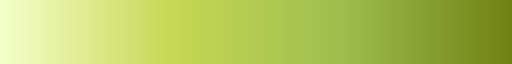

In [101]:
import colormaps as clrmps
clrmps.green_c_gry1_r

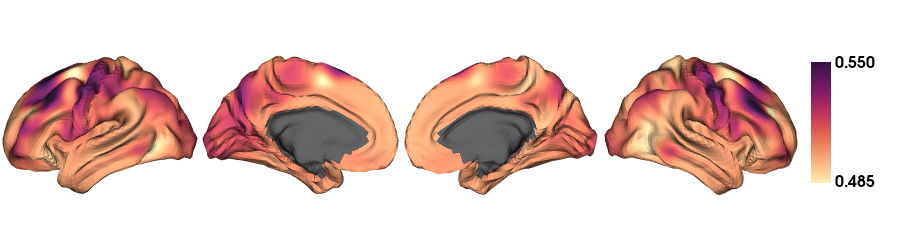

In [99]:
scrange=(np.quantile(grp_sill[mask_5k==True], 0.01), np.quantile(grp_sill[mask_5k==True], 0.99))
# Plot average SWM surfaces
plot_hemispheres(f5k_lh, f5k_rh, array_name=grp_sill_smooth, size=(900, 250), color_bar='right', zoom=1.25, embed_nb=True, interactive=False, share='both', nan_color=(0.3, 0.3, 0.3, 1),
                 cmap='matter', transparent_bg=False, screenshot=False, color_range=scrange)

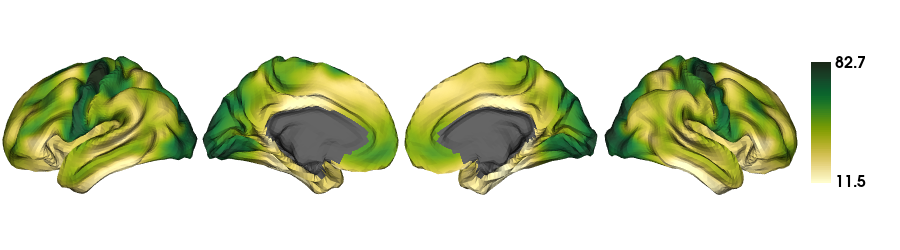

In [106]:
rcrange=(np.quantile(grp_range[mask_5k==True], 0.01), np.quantile(grp_range[mask_5k==True], 0.99))
# Plot average SWM surfaces
plot_hemispheres(f5k_lh, f5k_rh, array_name=grp_range_smooth, size=(900, 250), color_bar='right', zoom=1.25, embed_nb=True, interactive=False, share='both', nan_color=(0.3, 0.3, 0.3, 1), 
                 cmap='speed', transparent_bg=False, screenshot=False, color_range=rcrange)

## Linear regression with U-fiber/Long-range fiber

In [11]:
def masked_zscore(data, mask):
    out = np.full_like(data, np.nan, dtype=float)
    out[mask] = zscore(data[mask], nan_policy='omit')   
    return out

In [12]:
# 1) Difference maps (Δ = parallel – perpendicular)
dAFD = AFD_par_5k - AFD_perp_5k

# 2) Z-score normalization
dAFD_z = masked_zscore(dAFD, mask_surf)

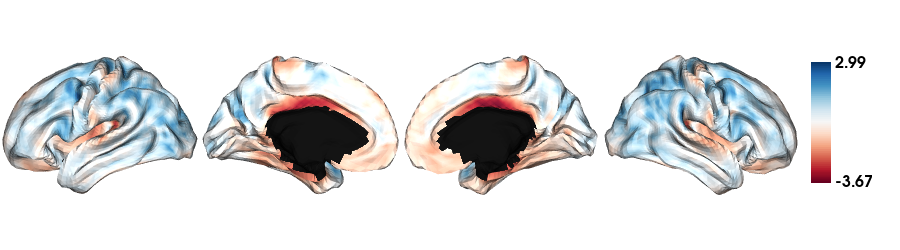

In [13]:
#dAFD_z[mask_5k==False] = np.nan
# Plot average SWM surfaces
plot_hemispheres(f5k_lh, f5k_rh, array_name=dAFD_z, size=(900, 250), color_bar='right', zoom=1.25, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='RdBu', transparent_bg=False, screenshot=False)

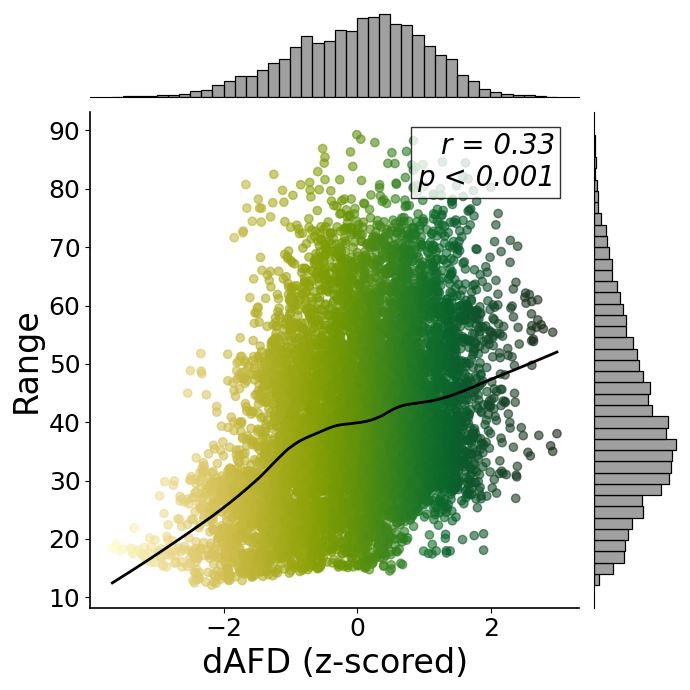

In [108]:
# -------------------------------------------------
# Prepare Data
# -------------------------------------------------
mod1 = copy.deepcopy(dAFD_z)
mod2 = copy.deepcopy(grp_range_smooth)

valid = ~np.isnan(mod1) & ~np.isnan(mod2)
x = mod1[valid]
y = mod2[valid]

# Spearman correlation
r, p = stats.spearmanr(x, y)

# -------------------------------------------------
# Create JointGrid
# -------------------------------------------------
g = sns.JointGrid(x=x, y=y, height=7, space=0)

# -------------------------------------------------
# Colormap centered at zero
# -------------------------------------------------
norm = mcolors.TwoSlopeNorm(
    vmin=np.min(x),
    vcenter=0,
    vmax=np.max(x)
)

sc = g.ax_joint.scatter(
    x, y,
    c=y,
    cmap='speed',
    norm=norm,
    alpha=0.6
)

# -------------------------------------------------
# LOWESS non-linear fit
# -------------------------------------------------
lowess_fit = lowess(y, x, frac=0.3)
g.ax_joint.plot(
    lowess_fit[:, 0],
    lowess_fit[:, 1],
    color='black',
    linewidth=2
)

# -------------------------------------------------
# Marginal Distributions
# -------------------------------------------------
sns.histplot(x=x, bins=40, ax=g.ax_marg_x, color='grey')
sns.histplot(y=y, bins=40, ax=g.ax_marg_y,
             color='grey', orientation='horizontal')

# Remove marginal tick labels
g.ax_marg_x.tick_params(bottom=False, labelbottom=False)
g.ax_marg_y.tick_params(left=False, labelleft=False)

# -------------------------------------------------
# Labels
# -------------------------------------------------
g.ax_joint.set_xlabel('dAFD (z-scored)', fontsize=24)
g.ax_joint.set_ylabel('Range', fontsize=24)

g.ax_joint.tick_params(axis='both', labelsize=18)

# p-value formatting
if p < 0.001:
    p_text = "< 0.001"
else:
    p_text = f"= {p:.3f}"

g.ax_joint.text(
    0.95, 0.85,
    f'r = {r:.2f}\np {p_text}',
    transform=g.ax_joint.transAxes,
    ha='right',
    bbox=dict(facecolor='white', alpha=0.8),
    fontsize=20,
    fontstyle='italic'
)

# -------------------------------------------------
# Spine thickness
# -------------------------------------------------
for spine in g.ax_joint.spines.values():
    spine.set_linewidth(1.2)


plt.tight_layout()
plt.show()

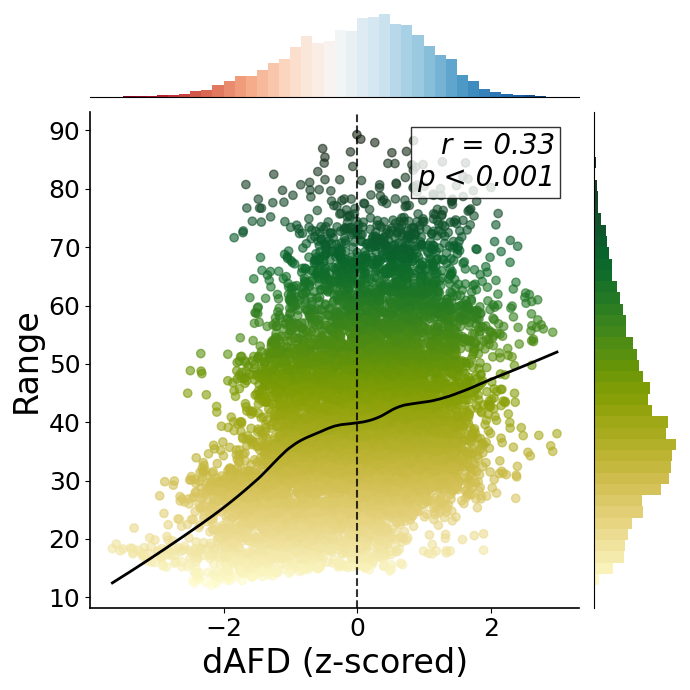

In [122]:
# -------------------------------------------------
# Prepare Data
# -------------------------------------------------
mod1 = copy.deepcopy(dAFD_z)
mod2 = copy.deepcopy(grp_range_smooth)

valid = ~np.isnan(mod1) & ~np.isnan(mod2)
x = mod1[valid]
y = mod2[valid]

# Spearman correlation
r, p = stats.spearmanr(x, y)

# -------------------------------------------------
# Create JointGrid
# -------------------------------------------------
g = sns.JointGrid(x=x, y=y, height=7, space=0)

# -------------------------------------------------
# Scatter colormap (BASED ON Y)
# -------------------------------------------------
ymin, ymax = np.min(y), np.max(y)

# robust normalization
if ymin < 0 < ymax:
    norm_scatter = mcolors.TwoSlopeNorm(
        vmin=ymin,
        vcenter=0,
        vmax=ymax
    )
else:
    norm_scatter = mcolors.Normalize(
        vmin=ymin,
        vmax=ymax
    )

sc = g.ax_joint.scatter(
    x, y,
    c=y,
    cmap='speed',
    norm=norm_scatter,
    alpha=0.6
)

# -------------------------------------------------
# LOWESS non-linear fit
# -------------------------------------------------
lowess_fit = lowess(y, x, frac=0.3)

g.ax_joint.plot(
    lowess_fit[:, 0],
    lowess_fit[:, 1],
    color='black',
    linewidth=2
)

g.ax_joint.axvline(
    x=0,
    linestyle='--',
    linewidth=1.5,
    color='black',
    alpha=0.8
)

# -------------------------------------------------
# Marginal Histograms with Colormaps
# -------------------------------------------------

# ---- X histogram (RdBu) ----
counts_x, bins_x = np.histogram(x, bins=40)
centers_x = 0.5 * (bins_x[:-1] + bins_x[1:])

norm_x = mcolors.Normalize(vmin=np.min(x), vmax=np.max(x))
cmap_x = plt.get_cmap("RdBu")

for c, left, right, h in zip(centers_x, bins_x[:-1], bins_x[1:], counts_x):
    g.ax_marg_x.bar(
        left,
        h,
        width=right-left,
        color=cmap_x(norm_x(c)),
        align='edge',
        #edgecolor='black',
        #linewidth=0.6
    )

# ---- Y histogram (matter) ----
counts_y, bins_y = np.histogram(y, bins=40)
centers_y = 0.5 * (bins_y[:-1] + bins_y[1:])

norm_y = mcolors.Normalize(vmin=np.min(y), vmax=np.max(y))
cmap_y = plt.get_cmap("speed")

for c, bottom, top, w in zip(centers_y, bins_y[:-1], bins_y[1:], counts_y):
    g.ax_marg_y.barh(
        bottom,
        w,
        height=top-bottom,
        color=cmap_y(norm_y(c)),
        align='edge',
        #edgecolor='black',
        #linewidth=0.6
    )

# -------------------------------------------------
# Clean marginal axes
# -------------------------------------------------
g.ax_marg_x.tick_params(bottom=False, labelbottom=False)
g.ax_marg_y.tick_params(left=False, labelleft=False)

# -------------------------------------------------
# Labels
# -------------------------------------------------
g.ax_joint.set_xlabel('dAFD (z-scored)', fontsize=24)
g.ax_joint.set_ylabel('Range', fontsize=24)
g.ax_joint.tick_params(axis='both', labelsize=18)

# p-value formatting
if p < 0.001:
    p_text = "< 0.001"
else:
    p_text = f"= {p:.3f}"

g.ax_joint.text(
    0.95, 0.85,
    f'r = {r:.2f}\np {p_text}',
    transform=g.ax_joint.transAxes,
    ha='right',
    bbox=dict(facecolor='white', alpha=0.8),
    fontsize=20,
    fontstyle='italic'
)

# -------------------------------------------------
# Spine thickness
# -------------------------------------------------
for spine in g.ax_joint.spines.values():
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

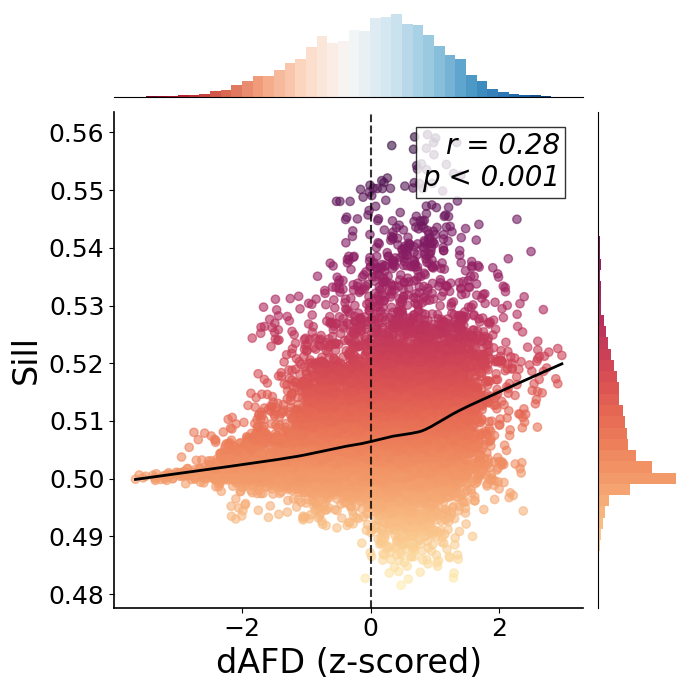

In [124]:
# -------------------------------------------------
# Prepare Data
# -------------------------------------------------
mod1 = copy.deepcopy(dAFD_z)
mod2 = copy.deepcopy(grp_sill_smooth)

valid = ~np.isnan(mod1) & ~np.isnan(mod2)
x = mod1[valid]
y = mod2[valid]

# Spearman correlation
r, p = stats.spearmanr(x, y)

# -------------------------------------------------
# Create JointGrid
# -------------------------------------------------
g = sns.JointGrid(x=x, y=y, height=7, space=0)

# -------------------------------------------------
# Scatter colormap (BASED ON Y)
# -------------------------------------------------
ymin, ymax = np.min(y), np.max(y)

# robust normalization
if ymin < 0 < ymax:
    norm_scatter = mcolors.TwoSlopeNorm(
        vmin=ymin,
        vcenter=0,
        vmax=ymax
    )
else:
    norm_scatter = mcolors.Normalize(
        vmin=ymin,
        vmax=ymax
    )

sc = g.ax_joint.scatter(
    x, y,
    c=y,
    cmap='matter',
    norm=norm_scatter,
    alpha=0.6
)

# -------------------------------------------------
# LOWESS non-linear fit
# -------------------------------------------------
lowess_fit = lowess(y, x, frac=0.3)

g.ax_joint.plot(
    lowess_fit[:, 0],
    lowess_fit[:, 1],
    color='black',
    linewidth=2
)

g.ax_joint.axvline(
    x=0,
    linestyle='--',
    linewidth=1.5,
    color='black',
    alpha=0.8
)

# -------------------------------------------------
# Marginal Histograms with Colormaps
# -------------------------------------------------

# ---- X histogram (RdBu) ----
counts_x, bins_x = np.histogram(x, bins=40)
centers_x = 0.5 * (bins_x[:-1] + bins_x[1:])

norm_x = mcolors.Normalize(vmin=np.min(x), vmax=np.max(x))
cmap_x = plt.get_cmap("RdBu")

for c, left, right, h in zip(centers_x, bins_x[:-1], bins_x[1:], counts_x):
    g.ax_marg_x.bar(
        left,
        h,
        width=right-left,
        color=cmap_x(norm_x(c)),
        align='edge',
        #edgecolor='black',
        #linewidth=0.6
    )

# ---- Y histogram (matter) ----
counts_y, bins_y = np.histogram(y, bins=40)
centers_y = 0.5 * (bins_y[:-1] + bins_y[1:])

norm_y = mcolors.Normalize(vmin=np.min(y), vmax=np.max(y))
cmap_y = plt.get_cmap("matter")

for c, bottom, top, w in zip(centers_y, bins_y[:-1], bins_y[1:], counts_y):
    g.ax_marg_y.barh(
        bottom,
        w,
        height=top-bottom,
        color=cmap_y(norm_y(c)),
        align='edge',
        #edgecolor='black',
        #linewidth=0.6
    )

# -------------------------------------------------
# Clean marginal axes
# -------------------------------------------------
g.ax_marg_x.tick_params(bottom=False, labelbottom=False)
g.ax_marg_y.tick_params(left=False, labelleft=False)

# -------------------------------------------------
# Labels
# -------------------------------------------------
g.ax_joint.set_xlabel('dAFD (z-scored)', fontsize=24)
g.ax_joint.set_ylabel('Sill', fontsize=24)
g.ax_joint.tick_params(axis='both', labelsize=18)

# p-value formatting
if p < 0.001:
    p_text = "< 0.001"
else:
    p_text = f"= {p:.3f}"

g.ax_joint.text(
    0.95, 0.85,
    f'r = {r:.2f}\np {p_text}',
    transform=g.ax_joint.transAxes,
    ha='right',
    bbox=dict(facecolor='white', alpha=0.8),
    fontsize=20,
    fontstyle='italic'
)

# -------------------------------------------------
# Spine thickness
# -------------------------------------------------
for spine in g.ax_joint.spines.values():
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

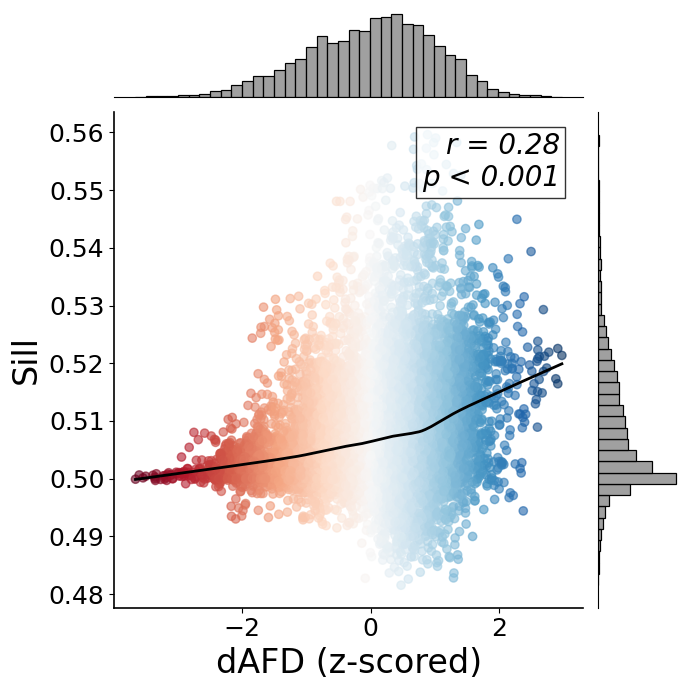

In [21]:
# -------------------------------------------------
# Prepare Data
# -------------------------------------------------
mod1 = copy.deepcopy(dAFD_z)
mod2 = copy.deepcopy(grp_sill_smooth)

valid = ~np.isnan(mod1) & ~np.isnan(mod2)
x = mod1[valid]
y = mod2[valid]

# Spearman correlation
r, p = stats.spearmanr(x, y)

# -------------------------------------------------
# Create JointGrid
# -------------------------------------------------
g = sns.JointGrid(x=x, y=y, height=7, space=0)

# -------------------------------------------------
# Colormap centered at zero
# -------------------------------------------------
norm = mcolors.TwoSlopeNorm(
    vmin=np.min(x),
    vcenter=0,
    vmax=np.max(x)
)

sc = g.ax_joint.scatter(
    x, y,
    c=x,
    cmap='RdBu',
    norm=norm,
    alpha=0.6
)

# -------------------------------------------------
# LOWESS non-linear fit
# -------------------------------------------------
lowess_fit = lowess(y, x, frac=0.3)
g.ax_joint.plot(
    lowess_fit[:, 0],
    lowess_fit[:, 1],
    color='black',
    linewidth=2
)

# -------------------------------------------------
# Marginal Distributions
# -------------------------------------------------
sns.histplot(x=x, bins=40, ax=g.ax_marg_x, color='grey')
sns.histplot(y=y, bins=40, ax=g.ax_marg_y,
             color='grey', orientation='horizontal')

# Remove marginal tick labels
g.ax_marg_x.tick_params(bottom=False, labelbottom=False)
g.ax_marg_y.tick_params(left=False, labelleft=False)

# -------------------------------------------------
# Labels
# -------------------------------------------------
g.ax_joint.set_xlabel('dAFD (z-scored)', fontsize=24)
g.ax_joint.set_ylabel('Sill', fontsize=24)

g.ax_joint.tick_params(axis='both', labelsize=18)

# p-value formatting
if p < 0.001:
    p_text = "< 0.001"
else:
    p_text = f"= {p:.3f}"

g.ax_joint.text(
    0.95, 0.85,
    f'r = {r:.2f}\np {p_text}',
    transform=g.ax_joint.transAxes,
    ha='right',
    bbox=dict(facecolor='white', alpha=0.8),
    fontsize=20,
    fontstyle='italic'
)

# -------------------------------------------------
# Spine thickness
# -------------------------------------------------
for spine in g.ax_joint.spines.values():
    spine.set_linewidth(1.2)


plt.tight_layout()
plt.show()